In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Constants 

In [ ]:
ROOT = "/kaggle/input/big-data-derby-2022"
INPUT_DIR = "/kaggle/input/big-derby-master"

RACE_PROGRAM_ID = ["race_id", "program_number"]
RACE_TYPES = ["STK", "ALW", "AOC", "MSW"]
RACE_TYPES_FULL = ["Stakes", "Allowance", "Allowance Optional Claiming", "Maiden Special Weight"]
COURSE_TYPES_FULL = ["Hurdle", "Dirt", "Outer turf", "Inner turf", "Turf"]
RACE_TYPE_MAP = {
    "STK": "Stakes",
    "ALW": "Allowance",
    "AOC": "Allowance Optional Claiming",
    "MSW": "Maiden Special Weight"
}
COURSE_TYPE_MAP = {
    "M": "Hurdle",
    "D": "Dirt",
    "O": "Outer turf",
    "I": "Inner turf",
    "T": "Turf"
}

TRACK_CONDITION_MAP = {
    "YL":"Yielding", 
    "FM":"Firm", 
    "SY":"Sloppy", 
    "GD":"Good", 
    "FT":"Fast", 
    "MY":"Muddy", 
    "SF":"Soft"
}

# Data

## Race Table
**Contains information regarding the race.**

`track_id` - 3 character id for the track the race took place at. AQU -Aqueduct, BEL - Belmont, SAR - Saratoga.

`race_date` - date the race took place. YYYY-MM-DD.

`race_number` - Number of the race. Passed as 3 characters but can be cast or converted to int for this data set.

`distance_id` - Distance of the race in furlongs passed as an integer. Example - 600 would be 6 furlongs.

`course_type` - The course the race was run over passed as one character. M - Hurdle, D - Dirt, O - Outer turf, I - Inner turf, T - turf.

`track_condition` - The condition of the course the race was run on passed as three characters. YL - Yielding, FM - Firm, SY - Sloppy, GD - Good, FT - Fast, MY - Muddy, SF - Soft.

`run_up_distance` - Distance in feet of the gate to the start of the race passed as an integer.

`race_type` - The classification of the race passed as as five characters. STK - Stakes, WCL - Waiver Claiming, WMC - Waiver Maiden Claiming, SST - Starter Stakes, SHP - Starter Handicap, CLM - Claiming, STR - Starter Allowance, AOC - Allowance Optionl Claimer, SOC - Starter Optional Claimer, MCL - Maiden Claiming, ALW - Allowance, MSW - Maiden Special Weight.

`purse` - Purse in US dollars of the race passed as an money with two decimal places.

`post_time` - Time of day the race began passed as 5 character. Example - 01220 would be 12:20.

In [ ]:
race = pd.read_csv(f"{INPUT_DIR}/race-updated.csv", parse_dates=["race_date"])
race = race[race.race_type.isin(RACE_TYPES)]
race["race_type_full"] = race.race_type.map(RACE_TYPE_MAP)
race["course_type_full"] = race.course_type.map(COURSE_TYPE_MAP)
race["track_condition"] = race["track_condition"].str.lstrip(" ").str.rstrip(" ")
race["track_condition_full"] = race.track_condition.map(TRACK_CONDITION_MAP)
race.head()

## Start Table

`track_id` - 3 character id for the track the race took place at. AQU -Aqueduct, BEL - Belmont, SAR - Saratoga.

`race_date` - date the race took place. YYYY-MM-DD.  

`race_number` - Number of the race. Passed as 3 characters but can be cast or converted to int for this data set.  

`program_number` - Program number of the horse in the race passed as 3 characters. Should remain 3 characters as it isn't limited to just numbers. Is essentially the unique identifier of the horse in the race.  

`weight_carried` - An integer of the weight carried by the horse in the race.  

`jockey` - Name of the jockey on the horse in the race. 50 character max.  

`odds` - Odds to win the race passed as an integer. Divide by 100 to derive the odds to 1. Example - 1280 would be 12.8-1.  

`position_at_finish` - An integer of the horse's finishing position. (added to the dataset 9/8/22)  

In [ ]:
start = pd.read_csv(f"{INPUT_DIR}/start-updated.csv", parse_dates=["race_date"])
start.head()

## Tracking table

**Contains information about the position of each horse throughout the race.**

`track_id` - 3 character id for the track the race took place at. AQU -Aqueduct, BEL - Belmont, SAR - Saratoga.

`race_date` - date the race took place. YYYY-MM-DD.

`race_number` - Number of the race. Passed as 3 characters but can be cast or converted to int for this data set.

`program_number` - Program number of the horse in the race passed as 3 characters. Should remain 3 characters as it isn't limited to just numbers. Is essentially the unique identifier of the horse in the race.

`trakus_index` - The common collection of point of the lat / long of the horse in the race passed as an integer. From what we can tell, it's collected every 0.25 seconds.

`latitude` - The latitude of the horse in the race passed as a float.

`longitude` - The longitude of the horse in the race passed as a float.

In [ ]:
tracking = pd.read_csv(f"{INPUT_DIR}/tracking-updated.csv")
tracking = tracking.sort_values(RACE_PROGRAM_ID)

In [ ]:
distance_cols = [*RACE_PROGRAM_ID, "cumulative_distance"]
race_cols = ["race_id", "track_distance", "course_type_full", "race_type_full"]

In [ ]:
tracking = tracking.merge(race[["race_id", "race_type", "race_type_full", "course_type_full", "track_condition_full"]], on=["race_id"])

In [ ]:
distance = tracking.loc[tracking.trakus_index.eq(tracking.finish_trakus_index), distance_cols]
distance = distance.merge(race[race_cols], on=["race_id"])
distance = distance.merge(start[[*RACE_PROGRAM_ID, "normalized_place"]], on=RACE_PROGRAM_ID)
distance["distance_vs_track"] = distance["cumulative_distance"].div(distance["track_distance"])

# Problem Statement

In this analysis, we try to analyze "What is the optimal strategy for a horse to run in the race?" We analyzed the distance and utilized our definition of "zone" to further analyze the rankings throughout the race, zones/zone changes throughout the race.

# Distance Analysis

One of my first thought when thinking about horse racing is to consider the distance ran. As an ex-cross country runner, I was taught by my coach to always be in the inner circle of the race to minimize the distance ran in the race. I wondered if that plays a role in horse racing as well. Maybe horses that place high in the race run the path that is more efficient than its fellow horses.

In this analysis, we will observe 

- Distribution of distance ran in each `course_type`, `race_type`
- Correlation between distance and finishing position
- Distance ran during each segment of the race

### Calculating the finishing trakus_index
First of all, to calculate the distance travelled in this race, it's important to figure out when each horse finishes in the race. This is because the winning horse usually finishes quite early compared to the last `trakus_index`. Therefore, this might inflate the distance ran by each horse. To do this, I follow this notebook from @shapital's [notebook][1]. I modified his code to use all numpy operations so that the processing can be done quickly.

### Calculating Distance
To calculate distance in meters, I had to convert all (latitude, longitude) into (x,y) values. I consider all (latitude, longitude) at `trakus_index` = 1 as the origin and computed all (x,y) using the formula in this [stackoverflow][2]. Because the distance of the race is relatively short, I assume that the Earth is flat and computed the distance using the Euclidean distance 

![Euclidean Distance][3]


[1]: https://www.kaggle.com/code/shapital/calculating-speed-turning-angle-and-position
[2]: https://stackoverflow.com/questions/24617013/convert-latitude-and-longitude-to-x-and-y-grid-system-using-python
[3]: https://www.researchgate.net/profile/Young-Sun-Lee-2/publication/263889770/figure/fig1/AS:890653479284740@1589359745492/An-example-of-Euclidean-distance-between-two-objects-on-variables-X-and-Y.png

### Distribution of Distance Ran in Each Race

In this analysis, I want to see the distribution of how far horses run compare to the distance of the race track. I normalize the distance ran by doing a simple division of 

$$\frac{race  distance}{track  distance}$$

Using race distance vs track distance, I created a boxplot for each course type


### Course Type

At the course type level we find that

- Outer turf has the lowest spread in terms of distance ran while turf and inner turf has far greater spread.
- Most course type has roughly the same center

In [ ]:
grid = sns.FacetGrid(data=distance, col="course_type_full", col_wrap=3, height=6, aspect=1.5)

grid.map(sns.boxplot, "distance_vs_track")
grid.set_titles(row_template='{row_name}', col_template="Course type: {col_name}")
plt.show()

### Race Type

At the race type level we find that

- These four races have similar distance distribution but Maiden Special Weight has the most spread.

In [ ]:
grid = sns.FacetGrid(data=distance, col="race_type_full", col_wrap=3, height=6, aspect=1.5)

grid.map(sns.boxplot, "distance_vs_track")
grid.set_titles(col_template="Race type: {col_name}")
plt.show()

### Correlation

Now, let's see whether there is any correlation between distance ran and the finishing position of the horse. Since different races have different number of horses competing, I normalize the finishing position by dividing `position_at_finish` by the number of horses participated in the race.

When analyzing by course type and race type, we found out that there is almost no correlation between distance and placing. Although there is no correlation, it is still too early to assume that distance plays no role in the race. We can find distance ran in each segment of the race to see if there will be a difference

In [ ]:
distance.groupby("course_type_full")[["distance_vs_track", "normalized_place"]].corr()

In [ ]:
distance.groupby("race_type_full")[["distance_vs_track", "normalized_place"]].corr()

In [ ]:
TRAKUS_INTERVAL = 5 # Intervene every x% of the race.

In [ ]:
tracking["trakus_prop"] = tracking["trakus_index"].div(tracking.groupby("race_id")["trakus_index"].transform("max"))
tracking["trakus_segment"] = tracking["trakus_prop"].floordiv(TRAKUS_INTERVAL / 100).add(1)

In [ ]:
group_cols = [*RACE_PROGRAM_ID, "race_type_full", "course_type_full", "trakus_segment", "finish_trakus_index"]
distance_by_segment = (
    tracking
   .loc[~tracking.dnf & ~tracking.is_finished]
   .groupby(group_cols)["cumulative_distance"]
   .agg(np.ptp)
   .reset_index()
)

In [ ]:
mean_distance_by_segment = distance_by_segment.groupby(["race_id", "trakus_segment"])["cumulative_distance"].transform("mean")
distance_by_segment["relative_distance"] = distance_by_segment["cumulative_distance"].div(mean_distance_by_segment)

distance_by_segment = distance_by_segment.merge(start[[*RACE_PROGRAM_ID, "normalized_place", "position_at_finish"]])

### Distance by Segment Analysis

#### Definition of a Segment
To perform segment analysis, we need to define the definition of segment first. The idea is that we can look at what percent the `trakus_index` is compared to the final `trakus_index`. Then, we can define a granularity level that checks the `trakus_index` every x% of the race. In this analysis, I control this to 5%, meaning that we change segment every 5% of the race. For example, if the final `trakus_index` is 100, we define 1-5 as segment 1, 6-10 as segment 2, etc., resulting in 20 total segments.

### Definition of Relative Distance
When looking at distance, we can analyze how much the horse ran compared to its peers. To do this, I introduce the concept of "Relative Distance", where we divide the distance ran by each horse during each segment divided by the average distance ran by all horses during each segment.

After defining segment and relative distance, I created a basic lineplot of segment (x) vs relative distance (y) group by course type, race type, and position at finish to see if there are any special patterns during each segment of the race.

### Findings
- The strategy in all of these races seem to be the same. The distance relative to its peers is roughly the same during the first half of the race while during the second half, the distance increases significantly.
- We see in this plot that high placers generally start to run more during the second half of the race compared to its peers. First and second place tend to start running more earlier than third and fourth place. 
- In all the race types except Stakes, first place tend to run more than its peers during the early and mid-final segment, resembling kind of a "U-Shape" in the plot. In stakes, distance of the first place starts to be different around mid-race forward.

**One hypothesis we have for this finding is that the good horses need to run more during these segment to get into a good position in the track. To quantify whether this is true, we performed zone-based analysis. This will be introduced later in the notebook**

In [ ]:
POSITIONS_TO_COMPARE = 4
FACET_ROW = "course_type_full"
FACET_COL = "position_at_finish"
POSITION_MASK = distance_by_segment.position_at_finish.le(POSITIONS_TO_COMPARE) 
GROUP_COLS = [FACET_ROW, FACET_COL, "trakus_segment"]

subset_data = distance_by_segment.loc[POSITION_MASK].groupby(GROUP_COLS)["relative_distance"].median().reset_index()

grid = sns.FacetGrid(
    data=subset_data, 
    row=FACET_ROW,
    col=FACET_COL, 
    height=2.5, 
    aspect=1.5,
    margin_titles=True,
    row_order=COURSE_TYPES_FULL
)

grid.map(sns.lineplot, "trakus_segment", "relative_distance")
grid.set_titles(row_template='{row_name}', col_template="Position at finish: {col_name}")

for ax in grid.axes.ravel():
    ax.axhline(1, linestyle="--")
    ax.set_ylim([0.98, 1.05])
    ax.set_xlabel("Segment")
    ax.set_ylabel("Relative distance")

In [ ]:
POSITIONS_TO_COMPARE = 4
FACET_ROW = "race_type_full"
FACET_COL = "position_at_finish"
POSITION_MASK = distance_by_segment.position_at_finish.le(POSITIONS_TO_COMPARE) 
GROUP_COLS = [FACET_ROW, FACET_COL, "trakus_segment"]

subset_data = distance_by_segment.loc[POSITION_MASK].groupby(GROUP_COLS)["relative_distance"].median().reset_index()

grid = sns.FacetGrid(
    data=subset_data, 
    row=FACET_ROW,
    col=FACET_COL, 
    height=2.5, 
    aspect=1.5,
    margin_titles=True,
    row_order=RACE_TYPES_FULL
)

grid.map(sns.lineplot, "trakus_segment", "relative_distance")
grid.set_titles(row_template='{row_name}', col_template="Position at finish: {col_name}")

for ax in grid.axes.ravel():
    ax.axhline(1, linestyle="--")
    ax.set_ylim([0.98, 1.045])
    ax.set_xlabel("Segment")
    ax.set_ylabel("Relative distance")

In [ ]:
tracking_sec = tracking.loc[tracking.trakus_index.mod(4).eq(0)].copy().reset_index(drop=True)

In [ ]:
# calculate normalized_trakus_index
max_trakus_index = (
    tracking_sec.groupby(["race_id"], as_index=False)["trakus_index"]
    .max().rename(columns={"trakus_index": "max_trakus_index"}))
tracking_sec = tracking_sec.merge(max_trakus_index, on=["race_id"])
tracking_sec["normalized_trakus_index"] = tracking_sec["trakus_index"] / tracking_sec["max_trakus_index"]

In [ ]:
tracking_pos = tracking_sec.merge(start[["position_at_finish", "race_id", "program_number"]], on=["race_id", "program_number"])

In [ ]:
def bin_trakus_index(trakus_index):
    if 0.0 < trakus_index <= 0.2:
        return "0 - 20"
    if 0.2 < trakus_index <= 0.4:
        return "20 - 40"
    if 0.4 < trakus_index <= 0.6:
        return "40 - 60"
    if 0.6 < trakus_index <= 0.8:
        return "60 - 80"
    if 0.8 < trakus_index <= 1.0:
        return "80 - 100"

tracking_pos["normalized_trakus_index_bin"] = tracking_pos["normalized_trakus_index"].apply(bin_trakus_index)

In [ ]:
course_rank_time_df = (
    tracking_pos
    .groupby(["position_at_finish", "course_type_full", 
              "race_id", "program_number", "normalized_trakus_index_bin"], as_index=False)
    ["rank"].agg(pd.Series.mode)
)

try:
    course_rank_time_df["rank"] = course_rank_time_df["rank"].apply(lambda x: x.min()).astype(int)
except AttributeError:
    pass

course_rank_time_df = (course_rank_time_df
                .groupby(["position_at_finish", "course_type_full","rank", "normalized_trakus_index_bin"])
                [["race_id"]].count())

course_rank_time_df = course_rank_time_df.reset_index()
course_rank_time_df.rename(columns={"race_id":"Count of horse"}, inplace=True)
course_rank_time_df

# Ranking by Segment Analysis
Not only can we compare the distance at each segment of the race, we can also compare the rank of the horses during each segment of the race.

This plot shows the pattern of rank along the race of each course type and the position at finish. The darker colour indicates the higher number of horses at that position. The columns of the grid show the course type and the row is the position at the finish. Within a single heatmap, the vertical axis is the rank along the race and the horizontal axis is the percentage of time ratio of races.

## Findings (Course Type)
- For the Dirt course type, most horses are in the first rank all along the race to be number 1 at the finish. A lot of horses that be in the first rank at the time 60% - 80% of the racing time can't make it to the last 20% the racing time and become the second at the finish. 

- For the Hurdle course type, it's hard to tell at the beginning, which one will be the first. Most of the time the 1st place at fish used to be rank 3 in the race. 

- For the Inner Turf course type, it's also hard to tell which one will be the winner. For 80% of the racing time, the horse distributes the position around the field and then spins at the last 20% of the racing time. 

- For the Outer Turf course type, most of the winner place at rank 1 all along the race. However, there is a strong pattern that the horse that stay the first rank for 80% of the racing time ends up as second place.

- For the Turf course type, the pattern is quite straightforward and the position at the finish can be concluded within 80% of the racing time.

In [ ]:
g = sns.FacetGrid(
    course_rank_time_df[course_rank_time_df["position_at_finish"] < 5], 
    col="course_type_full",  
    row="position_at_finish", 
    height=2.5, 
    aspect=1.5,
    margin_titles=True
)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g.map_dataframe(draw_heatmap, "normalized_trakus_index_bin", "rank", "Count of horse", cmap="YlGnBu", cbar=False)
g.set_axis_labels("Segment", "Rank")
plt.show()

In [ ]:
condition_rank_time_df = (
    tracking_pos
    .groupby(["position_at_finish", "track_condition_full", 
              "race_id", "program_number", "normalized_trakus_index_bin"], as_index=False)
    ["rank"].agg(pd.Series.mode)
)

try:
    condition_rank_time_df["rank"] = condition_rank_time_df["rank"].apply(lambda x: x.min()).astype(int)
except AttributeError:
    pass

condition_rank_time_df = (condition_rank_time_df
                .groupby(["position_at_finish", "track_condition_full","rank", "normalized_trakus_index_bin"])
                .count().max(axis=1))
condition_rank_time_df = condition_rank_time_df.reset_index()
condition_rank_time_df.rename(columns={0:"Count of horse"}, inplace=True)
condition_rank_time_df

## Findings (Track Condition)
- According to the plot, for all track types, we can guarantee the position at the finish by 80% of racing time, except Yielding. 

In [ ]:
g = sns.FacetGrid(
    condition_rank_time_df[condition_rank_time_df["position_at_finish"] < 5], 
    col="track_condition_full",  
    row="position_at_finish", 
    height=2.5, 
    aspect=1.5,
    margin_titles=True)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g.map_dataframe(draw_heatmap, "normalized_trakus_index_bin", "rank", "Count of horse", cmap="YlGnBu", cbar=False)
g.set_axis_labels("Segment", "Rank")
plt.show()

In [ ]:
type_rank_time_df = (
    tracking_pos
    .groupby(["position_at_finish", "race_type_full", 
              "race_id", "program_number", "normalized_trakus_index_bin"], as_index=False)
    ["rank"].agg(pd.Series.mode)
)

try:
    type_rank_time_df["rank"] = type_rank_time_df["rank"].apply(lambda x: x.min()).astype(int)
except AttributeError:
    pass

type_rank_time_df = (type_rank_time_df
                .groupby(["position_at_finish", "race_type_full","rank", "normalized_trakus_index_bin"])
                .count().max(axis=1))
type_rank_time_df = type_rank_time_df.reset_index()
type_rank_time_df.rename(columns={0:"Count of horse"}, inplace=True)
type_rank_time_df

## Findings (Race Type)

- Stakes is the only race where it is more clear who will win towards the finish of the race.

In [ ]:
g = sns.FacetGrid(type_rank_time_df[(type_rank_time_df["position_at_finish"] < 5) & (type_rank_time_df["race_type_full"].isin(RACE_TYPES_FULL))], 
                  col="race_type_full",  
                  row="position_at_finish", 
                  height=2.5, 
                  aspect=1.5,
                  margin_titles=True)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g.map_dataframe(draw_heatmap, "normalized_trakus_index_bin", "rank", "Count of horse", cmap="YlGnBu", cbar=False)
g.set_axis_labels("Segment", "Rank")
plt.show()

# Zone Analysis

Now, we introduce zone-analysis to analyze the position of each horse throughout the race. So how do we do this? 

## Step 1: Compute the Velocity Vector
First we need to know the direction where the horses are moving. This is because the track is a circle and we have to know the velocity vector in order to determine which horse is leading in the race in each segment.

At every second, we compute average position of the horse by averaging all the (latitude, longitude) values. Using this average position, we can then compute the velocity using the standard velocity formula
$$velocity = \frac{\Delta distance}{\Delta time}$$

Since we compute the velocity every second, $\Delta time$ is 1. 

## Step 2: Compute the Angle Between Horse's Position and Vector
After we have the velocity vector for all segments of the race, we compute the angle between the horse's position and the velocity vector.

This angle will tell us the "zone" of the horse in each segment. 

## Step 3: Defining Zone
We define six zones: front-right, front-left, right, left, back-right, and back-left as shown in the picture below:


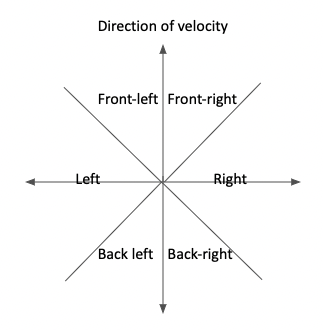

In [ ]:
tracking_sec["is_change_zone"] = tracking_sec["zone"].ne(tracking_sec.groupby(RACE_PROGRAM_ID)["zone"].shift(1))

finish_mask = tracking_sec.trakus_index.le(tracking_sec.finish_trakus_index) & ~tracking_sec.dnf
zone_change = tracking_sec.loc[finish_mask].groupby([*RACE_PROGRAM_ID, "race_type_full", "trakus_segment"])["is_change_zone"].sum().reset_index()

zone_change = zone_change.merge(start[[*RACE_PROGRAM_ID, "position_at_finish"]], on=RACE_PROGRAM_ID)

In [ ]:
zone_changes = [
    f"{zone1}_{zone2}"
    for zone1 in tracking_sec.zone.unique()
    for zone2 in tracking_sec.zone.unique()
    if zone1 != zone2
]

In [ ]:
tracking_sec[zone_changes] = pd.DataFrame(
    [
        np.where(
            tracking_sec.zone.eq(change.split("_")[0]) & 
            tracking_sec.groupby(RACE_PROGRAM_ID).zone.shift(1).eq(change.split("_")[1]),
            True,
            False
        )
        for change in zone_changes 
    ]
).transpose().reset_index(drop=True)

In [ ]:
tracking_sec_long = pd.melt(
    tracking_sec, 
    id_vars=[*RACE_PROGRAM_ID, "trakus_sec", "trakus_index", "trakus_segment", "finish_trakus_index", "race_type_full", "dnf"], 
    value_vars=zone_changes, 
    var_name="zone_change",
    value_name="count")

In [ ]:
finish_mask = tracking_sec_long.trakus_index.le(tracking_sec_long.finish_trakus_index) & ~tracking_sec.dnf
zone_change_detailed = tracking_sec_long.groupby([*RACE_PROGRAM_ID,"trakus_segment", "race_type_full", "zone_change"])["count"].sum().reset_index()
zone_change_detailed = zone_change_detailed.merge(start[[*RACE_PROGRAM_ID, "position_at_finish"]], on=RACE_PROGRAM_ID)

## Zone changes

Now, let's get back to the zone changes hypothesis that was introduced when analyzing distance at each segment.

To do this, we find during each segment of the race, what is the average number of times that there was a zone change. Since we thought it's important to know also what zone changes to what zone, we decided to create a plot that displays the detailed zone-change throughout the race as shown below. We also decided to analyze only the winning horse due to the high dimensionality of the data.

### Findings
- For all races, zone change occurs a lot during the start of the race. It seems that horses either want to be on the left or right zone. 
- Another segment where there is a significant zone change is towards the end of the race where horses either change from front-left to front-right or front-right to front-left. It seems that there is more change from front-left to front-right, suggesting that it might be strategic to be on the right side of the group during the last segment of th erace.

In [ ]:
POSITIONS_TO_COMPARE = 1
FACET_COL = "zone_change"
RACE_TYPES = zone_change_detailed.race_type_full.unique()
GROUP_COLS = [FACET_COL, "trakus_segment"]

for race_type in RACE_TYPES:
    print(race_type)
    POSITION_MASK = zone_change_detailed.position_at_finish.le(POSITIONS_TO_COMPARE) & zone_change_detailed.race_type_full.eq(race_type)

    subset_data = zone_change_detailed.loc[POSITION_MASK].groupby(GROUP_COLS)["count"].mean().reset_index()

    subset_data = subset_data[subset_data.groupby("zone_change")["count"].transform("sum").gt(0.05)]

    grid = sns.FacetGrid(
        data=subset_data, 
        col=FACET_COL, 
        col_wrap=5, 
        height=2.5, 
        aspect=1.5,
        margin_titles=True,
    #     row_order=RACE_TYPES_FULL
    )

    grid.map(sns.lineplot, "trakus_segment", "count")
    grid.set_titles(col_template="Zone change: {col_name}")
    plt.show()

# Zone Overview Analysis

In this analysis, we try to see the distribution of the zones throughout the race and also the rank corresponding with the zone

In [ ]:
stakes_df = tracking_pos[tracking_pos["race_type_full"] == "Stakes"]
zone_rank_time_df = (
    stakes_df
    .groupby(["position_at_finish", "zone", 
              "race_id", "program_number", "normalized_trakus_index_bin"], as_index=False)
    ["rank"].agg(pd.Series.mode)
)

try:
    zone_rank_time_df["rank"] = zone_rank_time_df["rank"].apply(lambda x: x.min()).astype(int)
except AttributeError:
    pass

zone_rank_time_df = (zone_rank_time_df
                .groupby(["position_at_finish", "zone", "rank", "normalized_trakus_index_bin"])
                .count().max(axis=1))

zone_rank_time_df = zone_rank_time_df.reset_index()
zone_rank_time_df.rename(columns={0:"Count of horse"}, inplace=True)

## Stakes

In [ ]:
zone_rank_time_df = zone_rank_time_df.sort_values(by="normalized_trakus_index_bin")
g = sns.FacetGrid(zone_rank_time_df[zone_rank_time_df["position_at_finish"] < 5], 
                  row="position_at_finish",  
                  col="normalized_trakus_index_bin", 
                  height=2.5, 
                  aspect=1.5,
                  margin_titles=True)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g.map_dataframe(draw_heatmap, "zone", "rank", "Count of horse", cmap="flare", cbar=False)
g.set_axis_labels("Segment", "Rank")
g.set_titles(row_template='Position at finish: {row_name}', col_template="Segment: {col_name}")
plt.show()

## Allowance

In [ ]:
allowance_df = tracking_pos[tracking_pos["race_type_full"] == "Allowance"]
zone_rank_time_df = (
    allowance_df
    .groupby(["position_at_finish", "zone", 
              "race_id", "program_number", "normalized_trakus_index_bin"], as_index=False)
    ["rank"].agg(pd.Series.mode)
)

try:
    zone_rank_time_df["rank"] = zone_rank_time_df["rank"].apply(lambda x: x.min()).astype(int)
except AttributeError:
    pass

zone_rank_time_df = (zone_rank_time_df
                .groupby(["position_at_finish", "zone", "rank", "normalized_trakus_index_bin"])
                .count().max(axis=1))

zone_rank_time_df = zone_rank_time_df.reset_index()
zone_rank_time_df.rename(columns={0:"Count of horse"}, inplace=True)

In [ ]:
zone_rank_time_df = zone_rank_time_df.sort_values(by="normalized_trakus_index_bin")
g = sns.FacetGrid(zone_rank_time_df[zone_rank_time_df["position_at_finish"] < 5], 
                  row="position_at_finish",  
                  col="normalized_trakus_index_bin", 
                  height=2.5, 
                  aspect=1.5,
                  margin_titles=True)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g.map_dataframe(draw_heatmap,  "zone", "rank", "Count of horse", cmap="flare", cbar=False)
g.set_axis_labels("Segment", "Rank")
g.set_titles(row_template='Position at finish: {row_name}', col_template="Segment: {col_name}")
plt.show()

## Allowance Optional Claiming

In [ ]:
allowanceOP_df = tracking_pos[tracking_pos["race_type_full"] == "Allowance Optional Claiming"]
zone_rank_time_df = (
    allowanceOP_df
    .groupby(["position_at_finish", "zone", 
              "race_id", "program_number", "normalized_trakus_index_bin"], as_index=False)
    ["rank"].agg(pd.Series.mode)
)

try:
    zone_rank_time_df["rank"] = zone_rank_time_df["rank"].apply(lambda x: x.min()).astype(int)
except AttributeError:
    pass

zone_rank_time_df = (zone_rank_time_df
                .groupby(["position_at_finish", "zone", "rank", "normalized_trakus_index_bin"])
                .count().max(axis=1))

zone_rank_time_df = zone_rank_time_df.reset_index()
zone_rank_time_df.rename(columns={0:"Count of horse"}, inplace=True)

In [ ]:
zone_rank_time_df = zone_rank_time_df.sort_values(by="normalized_trakus_index_bin")
g = sns.FacetGrid(zone_rank_time_df[zone_rank_time_df["position_at_finish"] < 5], 
                  row="position_at_finish",  
                  col="normalized_trakus_index_bin", 
                  height=2.5, 
                  aspect=1.5,
                  margin_titles=True)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g.map_dataframe(draw_heatmap,  "zone", "rank", "Count of horse", cmap="flare", cbar=False)
g.set_axis_labels("Segment", "Rank")
g.set_titles(row_template='Position at finish: {row_name}', col_template="Segment: {col_name}")
plt.show()

## Maiden Special Weight

In [ ]:
msw_df = tracking_pos[tracking_pos["race_type_full"] == "Maiden Special Weight"]
zone_rank_time_df = (
    msw_df
    .groupby(["position_at_finish", "zone", 
              "race_id", "program_number", "normalized_trakus_index_bin"], as_index=False)
    ["rank"].agg(pd.Series.mode)
)

try:
    zone_rank_time_df["rank"] = zone_rank_time_df["rank"].apply(lambda x: x.min()).astype(int)
except AttributeError:
    pass

zone_rank_time_df = (zone_rank_time_df
                .groupby(["position_at_finish", "zone", "rank", "normalized_trakus_index_bin"])
                .count().max(axis=1))

zone_rank_time_df = zone_rank_time_df.reset_index()
zone_rank_time_df.rename(columns={0:"Count of horse"}, inplace=True)

In [ ]:
zone_rank_time_df = zone_rank_time_df.sort_values(by="normalized_trakus_index_bin")
g = sns.FacetGrid(zone_rank_time_df[zone_rank_time_df["position_at_finish"] < 5], 
                  row="position_at_finish",  
                  col="normalized_trakus_index_bin", 
                  height=2.5, 
                  aspect=1.5,
                  margin_titles=True)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g.map_dataframe(draw_heatmap, "zone", "rank", "Count of horse", cmap="flare", cbar=False)
g.set_axis_labels("Segment", "Rank")
g.set_titles(row_template='Position at finish: {row_name}', col_template="Segment: {col_name}")
plt.show()

# Conclusion

From the analysis that we've done above, we found out the following
- High placing horses tended to run more during the start and middle of the race onwards. 
- When there is a zone-change, horses tend to move to the left or the right early in the race. Towards the end of the race, there is always a change between front-left and front-right with more horses changing to front-right.
- Most of the time, horses that win are already in front for most of the race. Stakes is one race type that is more unpredictable.

## Suggestions

**The strategic position at the start to be number 1 at the finish is zone front-left and try to stay in this position till the end of the race. It's obviously the shortest distance to run. However, if the jockey can't put the horse at the front-left, try to stay front-right. In case the jockey can't put the horse at the front, the right zone can be an option. Because most of the jockeys try to be on the left to run on the shortest path and overtake the others, that jams the left zone. So, staying on right and saving energy for the last 20% of the racing time can be another strategic plan to be the winner.**